# NonBScanner - Local Analysis Workflow (Unlimited)

**Complete workflow for Non-B DNA motif detection and analysis**

## 🚀 Local Version Advantages

| Feature | Local Version | Web Version |
|---------|--------------|-------------|
| **Sequence Length** | ✅ **UNLIMITED** | 1,000,000 nt max |
| **Genome-scale Analysis** | ✅ Full genomes | Chunked analysis |
| **Processing** | Multi-core parallel | Single-threaded |
| **Memory** | Local RAM | Cloud limited |

This notebook provides a streamlined approach to:
1. **Setup & Analysis**: Import libraries and analyze FASTA sequences of ANY size
2. **Results & Export**: View results and export to Excel/CSV
3. **Visualization**: Generate comprehensive plots and statistics

---

## Motif Detection Parameters

| Motif Type | Arm/Unit Length | Spacer/Loop | Additional Requirements |
|------------|-----------------|-------------|-------------------------|
| **Cruciform DNA** | 10–100 nt | 0–3 nt | Reverse complement arms |
| **Slipped DNA** | 10–50 nt repeat | 0 nt (adjacent) | Direct repeat units |
| **Triplex DNA** | 10–100 nt mirrored | 0–8 nt | ≥90% Purine or Pyrimidine |

---

## Box 1: Setup and Analysis

### Import Libraries and Analyze Sequences

Total Classes: 11
Found 1 .fna files in 'input_fna'

Processing input_fna\hpylori.fna -> results\hpylori
Analyzing NZ_CP024072.1 Helicobacter pylori strain 7.13_R1b chromosome, complete genome (1,674,010 bp)
Exports saved to results\hpylori
Plotting skipped: plot_motif_distribution() got an unexpected keyword argument 'save_path'
File summary: 12221 motifs, 1,674,010 bp

ALL FILES PROCESSED
Total runtime: 148.16s, Total bp: 1,674,010, Speed: 11,299 bp/s
Total motifs: 12221; Total kb: 1674.01

Motif distribution (top 10):
Class
G-Quadruplex          3518
Slipped_DNA           3037
Curved_DNA            2799
Non-B_DNA_Clusters    2486
Hybrid                 230
A-philic_DNA            55
Cruciform               28
Z-DNA                   22
i-Motif                 22
Triplex                 22
Name: count, dtype: int64
Saved visualization: nbdscanner_visualizations.png
Saved consolidated exports.


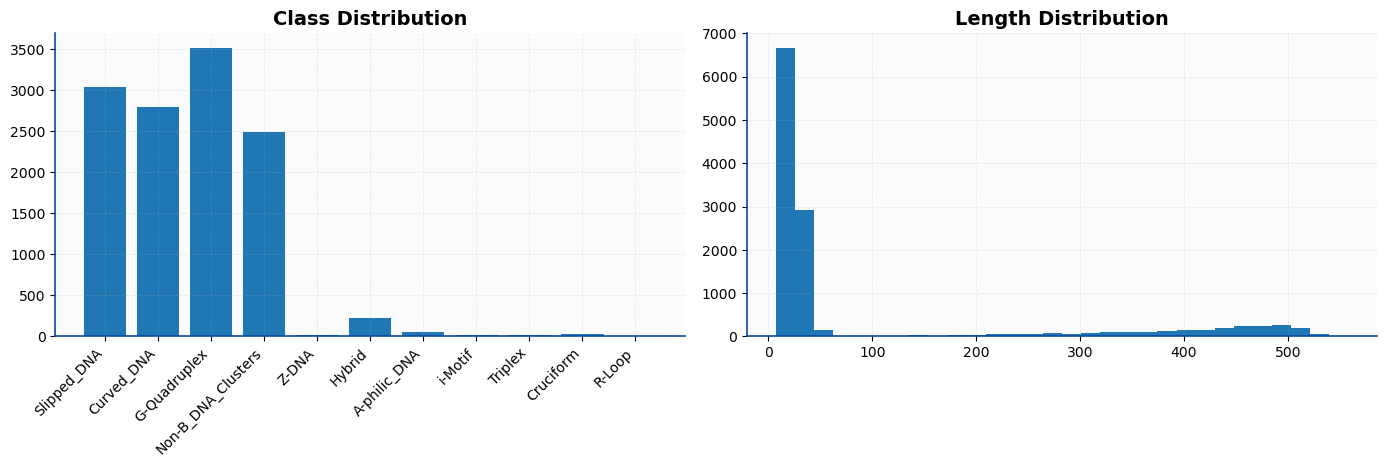

In [5]:
# Minimal ready-to-paste patch: fixes DataFrame truthiness, ensures per-file summaries,
# computes overall_speed, and normalizes exports to list-of-dicts.
# Paste-replaces your main script (keeps original interfaces).

import time, os, glob
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import display

# nonbscanner modules (assumed available)
from nonbscanner import analyze_sequence, get_motif_info
from utilities import (
    read_fasta_file, export_to_excel, export_to_csv, export_to_json,
    export_results_to_dataframe
)
from visualizations import (
    plot_motif_distribution, plot_coverage_map, plot_length_distribution,
    plot_score_distribution, plot_radial_class_density, plot_stacked_density_track
)

# params
CHUNK_SIZE, OVERLAP = 10000, 500
INPUT_FOLDER, OUTPUT_FOLDER = "input_fna", "results"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

motif_info = get_motif_info()
print("Total Classes:", motif_info.get("total_classes", 0))

def chunk_sequence(seq, chunk_size=CHUNK_SIZE, overlap=OVERLAP):
    i, n, cid, out = 0, len(seq), 0, []
    while i < n:
        start = i; end = min(i + chunk_size, n)
        out.append((cid, start, end, seq[start:end]))
        i += chunk_size - overlap; cid += 1
    return out

def adjust_motif_positions(motifs, chunk_start):
    return [{**m, **({"Start": m["Start"] + chunk_start} if "Start" in m else {}),
             **({"End": m["End"] + chunk_start} if "End" in m else {})} for m in motifs]

def dedupe_motifs(motifs):
    seen = set(); uniq = []
    for m in motifs:
        key = (m.get("Start"), m.get("End"), m.get("Class",""))
        if key not in seen:
            seen.add(key); uniq.append(m)
    return uniq

# globals
fna_files = glob.glob(os.path.join(INPUT_FOLDER, "*.fna"))
print(f"Found {len(fna_files)} .fna files in '{INPUT_FOLDER}'")
all_results = []
global_total_bp = 0
start_time = time.time()

for fasta_file in fna_files:
    base = os.path.basename(fasta_file).rsplit(".fna",1)[0]
    outdir = os.path.join(OUTPUT_FOLDER, base); os.makedirs(outdir, exist_ok=True)
    print(f"\nProcessing {fasta_file} -> {outdir}")

    sequences = read_fasta_file(fasta_file)
    file_all_motifs = []
    file_total_bp = 0
    file_analysis_times = []

    for seq_name, seq in sequences.items():
        print(f"Analyzing {seq_name} ({len(seq):,} bp)")
        seq_motifs = []; t0_seq = time.time()
        for cid, start, end, chunk_seq in chunk_sequence(seq):
            chunk_res = analyze_sequence(chunk_seq, f"{seq_name}_chunk{cid}")
            seq_motifs.extend(adjust_motif_positions(chunk_res, start))
        seq_motifs = dedupe_motifs(seq_motifs)
        dt = time.time() - t0_seq
        file_analysis_times.append({"name": seq_name, "length": len(seq), "motifs": len(seq_motifs), "time": dt})
        for m in seq_motifs: m["Sequence_Name"] = seq_name
        file_all_motifs.extend(seq_motifs)
        file_total_bp += len(seq)

    # normalize exports: pass list-of-dicts (utilities expects iterable)
    records = file_all_motifs  # already list of dicts
    df = pd.DataFrame(records) if records else pd.DataFrame()

    # write outputs (utilities will create files if filename passed)
    csv_path = os.path.join(outdir, f"{base}_motifs.csv")
    xlsx_path = os.path.join(outdir, f"{base}_motifs.xlsx")
    json_path = os.path.join(outdir, f"{base}_motifs.json")

    try:
        export_to_csv(records, csv_path)
        export_to_excel(records, xlsx_path)
        export_to_json(records, json_path)
        print("Exports saved to", outdir)
    except Exception as e:
        # fallback: write DataFrame directly if utilities misbehave
        if not df.empty:
            df.to_csv(csv_path, index=False)
            df.to_excel(xlsx_path, index=False)
            df.to_json(json_path, orient="records")
            print("Fallback exports saved to", outdir)
        else:
            print("No motifs to export for", base)

    # optional plots (safe-guard)
    try:
        if not df.empty:
            plot_motif_distribution(df, save_path=os.path.join(outdir,"motif_distribution.png"))
            plot_coverage_map(df, seq_length=file_total_bp, save_path=os.path.join(outdir,"coverage_map.png"))
            plot_length_distribution(df, save_path=os.path.join(outdir,"length_distribution.png"))
            plot_score_distribution(df, save_path=os.path.join(outdir,"score_distribution.png"))
    except Exception as e:
        print("Plotting skipped:", e)

    # append file summary for downstream visuals
    all_results.append({
        "name": base,
        "motifs": records,
        "sequence_lengths": {k: len(v) for k,v in sequences.items()},
        "total_length": file_total_bp,
        "analysis_times": file_analysis_times
    })
    global_total_bp += file_total_bp
    print(f"File summary: {len(records)} motifs, {file_total_bp:,} bp")

# final global metrics
total_time = time.time() - start_time
overall_speed = global_total_bp / total_time if total_time > 0 else 0
print("\nALL FILES PROCESSED")
print(f"Total runtime: {total_time:.2f}s, Total bp: {global_total_bp:,}, Speed: {overall_speed:,.0f} bp/s")

# consolidated DataFrame for summaries (use utilities if available)
all_motifs = [m for res in all_results for m in res["motifs"]]
df_results = export_results_to_dataframe(all_motifs) if all_motifs else pd.DataFrame()

# display basic summaries
sequence_kb = global_total_bp / 1000 if global_total_bp else 0
print(f"Total motifs: {len(all_motifs)}; Total kb: {sequence_kb:.2f}")
if not df_results.empty:
    class_counts = df_results['Class'].value_counts()
    print("\nMotif distribution (top 10):")
    print(class_counts.head(10))

# minimal visualization save (main plots)
try:
    fig = plt.figure(figsize=(14,8))
    # class distribution
    ax = fig.add_subplot(2,2,1)
    counts = Counter([m.get('Class','Unknown') for m in all_motifs])
    ax.bar(counts.keys(), counts.values()); ax.set_xticklabels(list(counts.keys()), rotation=45, ha='right')
    ax.set_title("Class Distribution")
    # length histogram
    ax2 = fig.add_subplot(2,2,2)
    ax2.hist([m.get('Length',0) for m in all_motifs], bins=30)
    ax2.set_title("Length Distribution")
    plt.tight_layout()
    plt.savefig('nbdscanner_visualizations.png', dpi=150)
    print("Saved visualization: nbdscanner_visualizations.png")
except Exception as e:
    print("Visualization error:", e)

# save consolidated exports in working dir (normalized)
try:
    export_to_excel(all_motifs, "nbdscanner_results.xlsx")
    export_to_csv(all_motifs, "nbdscanner_results.csv")
    export_to_json(all_motifs, "nbdscanner_results.json")
    print("Saved consolidated exports.")
except Exception:
    # fallback using pandas
    if all_motifs:
        pd.DataFrame(all_motifs).to_excel("nbdscanner_results.xlsx", index=False)
        pd.DataFrame(all_motifs).to_csv("nbdscanner_results.csv", index=False)
        pd.DataFrame(all_motifs).to_json("nbdscanner_results.json", orient="records")
        print("Fallback consolidated exports saved.")
